# Pipeline experimentation
This notebook contains the experiments regarding the measure of different extraction pipelines

In [1]:
import sys
sys.path.append('/home/jovyan/BenchmarkingML4KGE_extraction')

from utils.XMLParser import XMLParser
from utils.grobid_service import GrobidService
from utils import experimentation_utils
import json
from tqdm.auto import tqdm
from bert_score import score
import torch
import time
from gliner import GLiNER
import logging
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

with open('../data/dataset_con_rutas_xml.json', 'r', encoding='utf-8') as f:
    kge_dataset=json.load(f)

service=GrobidService()


/home/jovyan/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/jovyan/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Higher F1-Score pipeline

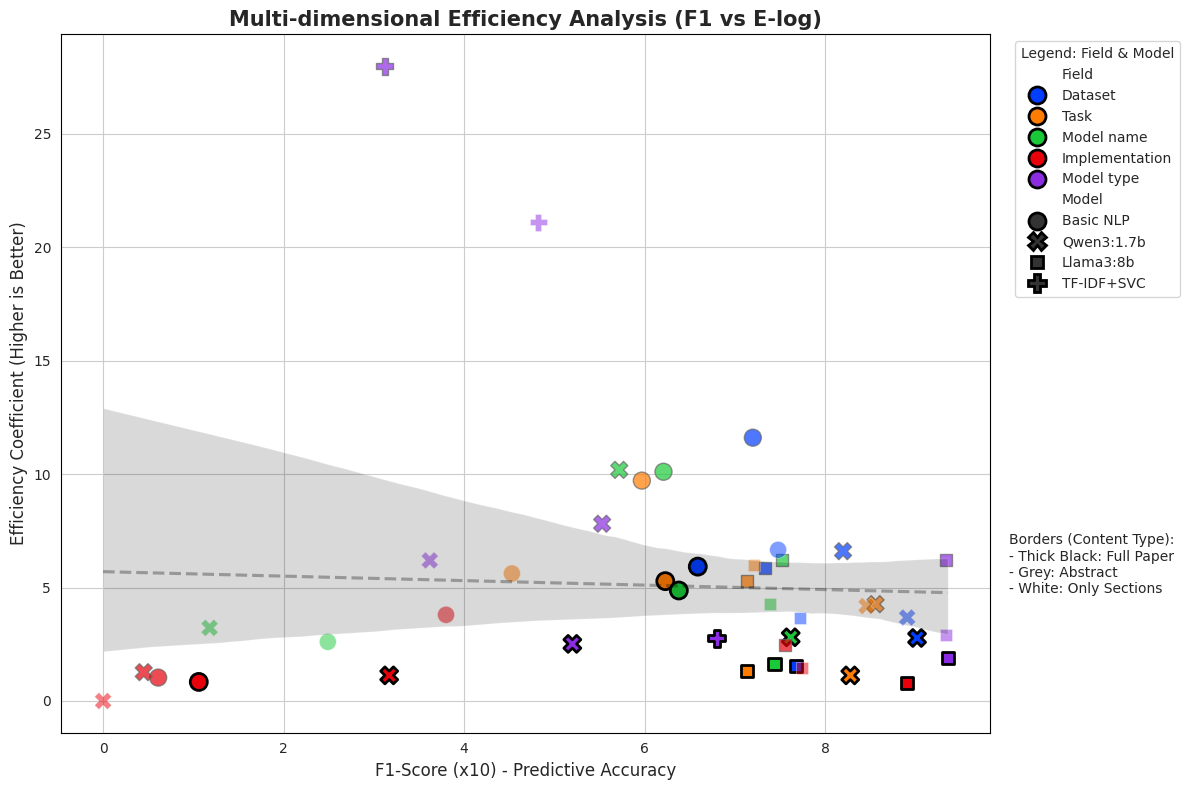

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 1. Carga y limpieza de datos (mismo proceso)
csv_data = """Field,Model,Merged,E_Full_paper,E_Abstract,E_Only_sections,F1_Full_paper,F1_Abstract,F1_Only_sections
Dataset,Basic NLP,Dataset-Basic NLP,5.923,11.607,6.663,6.59,7.2,7.48
,Qwen3:1.7b,Dataset-Qwen3:1.7b,2.778,6.603,3.677,9.02,8.2,8.91
,Llama3:8b,Dataset-Llama3:8b,1.559,5.865,3.652,7.68,7.34,7.72
Task,Basic NLP,Task-Basic NLP,5.283,9.715,5.619,6.23,5.97,4.53
,Qwen3:1.7b,Task-Qwen3:1.7b,1.128,4.268,4.184,8.28,8.56,8.46
,Llama3:8b,Task-Llama3:8b,1.305,5.296,5.996,7.14,7.14,7.21
Model name,Basic NLP,Model name-Basic NLP,4.871,10.105,2.607,6.38,6.21,2.49
,Qwen3:1.7b,Model name-Qwen3:1.7b,2.808,10.188,3.222,7.62,5.72,1.18
,Llama3:8b,Model name-Llama3:8b,1.615,6.220,4.296,7.44,7.52,7.39
Implementation,Basic NLP,Implementation-Basic NLP,0.840,1.031,3.799,1.06,0.61,3.8
,Qwen3:1.7b,Implementation-Qwen3:1.7b,1.129,1.270,0.0,3.17,0.45,0.0
,Llama3:8b,Implementation-Llama3:8b,0.804,2.474,1.460,8.91,7.56,7.74
Model type,TF-IDF+SVC,Model type-TF-IDF+SVC,2.775,27.989,21.103,6.8,3.12,4.82
,Qwen3:1.7b,Model type-Qwen3:1.7b,2.517,7.813,6.196,5.2,5.53,3.62
,Llama3:8b,Model type-Llama3:8b,1.881,6.208,2.919,9.36,9.34,9.34
"""

df = pd.read_csv(io.StringIO(csv_data))
df['Field'] = df['Field'].ffill()

rows = []
for _, r in df.iterrows():
    for s in ['Full_paper', 'Abstract', 'Only_sections']:
        try:
            rows.append({
                'Field': r['Field'], 'Model': r['Model'],
                'Content Type': s.replace('_', ' ').title(),
                'Efficiency': float(str(r[f'E_{s}']).replace(',', '.')),
                'F1': float(str(r[f'F1_{s}']).replace(',', '.'))
            })
        except: continue

df_plot = pd.DataFrame(rows)

# 2. Configuración estética
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid", {'axes.edgecolor': 'black'})
palette = sns.color_palette("bright", n_colors=len(df_plot['Field'].unique()))

# 3. Dibujamos los puntos con bordes diferenciados para el Content Type
# Usamos un bucle para tener control total sobre el 'edgecolor' y 'linewidth'
content_styles = {
    'Full Paper':    {'edgecolor': 'black', 'linewidth': 2.0, 'alpha': 1.0},
    'Abstract':      {'edgecolor': '#666666', 'linewidth': 1.0, 'alpha': 0.7},
    'Only Sections': {'edgecolor': 'white', 'linewidth': 0.5, 'alpha': 0.5}
}

for content_name, style_params in content_styles.items():
    subset = df_plot[df_plot['Content Type'] == content_name]
    sns.scatterplot(
        data=subset, x='F1', y='Efficiency', hue='Field', style='Model',
        s=150, palette=palette, legend=(content_name == 'Full Paper'),
        edgecolor=style_params['edgecolor'], 
        linewidth=style_params['linewidth'],
        alpha=style_params['alpha']
    )

# Añadimos la línea de tendencia general
sns.regplot(data=df_plot, x='F1', y='Efficiency', scatter=False, 
            color='black', line_kws={'linestyle': '--', 'alpha': 0.3})

# 4. Ajustes finales para Overleaf
plt.title('Multi-dimensional Efficiency Analysis (F1 vs E-log)', fontsize=15, weight='bold')
plt.xlabel('F1-Score (x10) - Predictive Accuracy', fontsize=12)
plt.ylabel('Efficiency Coefficient (Higher is Better)', fontsize=12)

# Mejorar la leyenda
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legend: Field & Model")
plt.text(1.02, 0.2, "Borders (Content Type):\n- Thick Black: Full Paper\n- Grey: Abstract\n- White: Only Sections", 
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(boxstyle="round", facecolor="white", alpha=0.5))

plt.tight_layout()
plt.savefig('scientific_plot_high_contrast.png', dpi=300)
plt.show()